# 딥러닝 ① FOCUS ON IMAGE + SEQUENCE

## 1. 합성곱 신경망 (CNN)  
  
> 이미지 인식의 혁신  
  
**픽셀**  
- 입력 이미지의 가장 기본적인 데이터 단위
- 이미지의 각 점에서 밝기/색상을 나타내는 값
- 각 픽셀은 단색의 직사각형, 전체 이미지으 크기는 (세로 픽셀 수*가로 픽셀 수) 형식으로 표현
- 이미지 데이터를 저장할 때는 픽셀의 색을 표현하는 값을 2차원 배열(Numpy ndarray)로 표현
  
  
[픽셀 값]  
- 흑백 이미지: 0(검은색)~255(흰색)
- 컬러 이미지: RGB 각각 0~255. (x, y, z)에서 RGB 순서대로 x가 Red, y가 Green, z가 Blue  
  
**채널**  
[색공간]  
- 픽셀의 색을 숫자로 표현하는 방식
- 대표적인 색공간: 그레이스케일(Gray Scale), RGB(Red-Green-Blue), HSV(Hue-Saturation-Value/색-채도-명도)
  
1. 그레이 스케일 (흑백 이미지)
- 채널 값=1
- 각 픽셀은 명도를 나타내는 숫자로 표현
    - 0이 검은색, 숫자 커질수록 하얀색
    - 해당 숫자는 0~255 사이의 8비트 부호 없는 정수로 저장
  
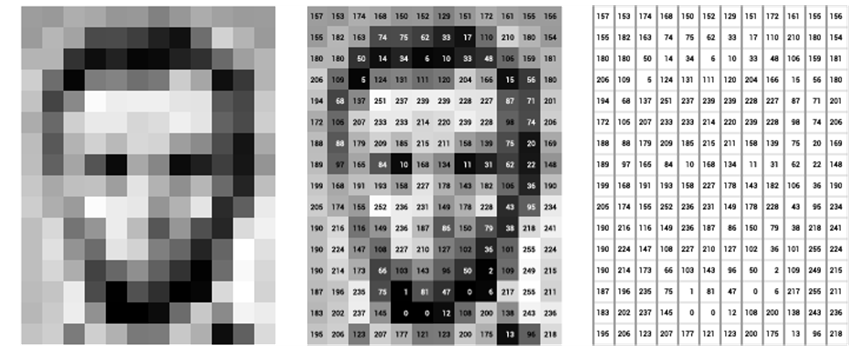  
  
- 이미지 데이터는 (채널 * 세로 픽셀 수 * 가로 픽셀 수) 형태의 2차원 배열로 저장
  

2. RGB (컬러 이미지)
- 채널 값=3
- Red, Green, Blue 3가지 색의 명도를 뜻하는 숫자 3개가 합쳐진 벡터로 표현
    - 특정 지점에서 Red 명도, Green 명도, Blue 명도가 합쳐져서 하나의 색을 형성 (얼마나 섞는지)
- 이미지 데이터는 (3 * 세로 픽셀 수 * 가로 픽셀 수) 형태의 3차원 배열로 저장
  
### CNN 개념  
  
**원본 이미지**: 컴퓨터는 이미지를 인식할 수 없으므로, 컴퓨터가 이해할 수 있도록 픽셀 단위로 구분  
**픽셀 단위로 나눈 이미지**: 각 픽셀에 대해 RGB 값이 적절히 조합되어 하나의 픽셀의 색 정보 나타냄  
  
[사람이 이미지를 보고 강아지/고양이 구분하는 법]  
- 물체가 존재하는 영역 위주로 살펴봄 (이미지 전체 보진 X) 
- 물체의 특징 위주로 봄 (물체 전체를 보진 X)  
  
**CNN**: 이미지 공간정보를 유지한 상태로 학습이 가능한 방식  
- (Conv+Pool)으로 특징 유지 -> FC Layer 적용 -> classification 진행
    - MLP: FC Layer 활용 -> classification 진행  
    
### 1-1. 왜 이미지 처리에 MLP가 아닌 CNN을 사용할까?  
  
[이미지 데이터의 구조]  
- 데이터 형식: 개별 값을 H⨉W 행렬로 나타낼 수 있음.
    - 컬러의 경우 H⨉W⨉3 구조
- MNIST: 대표적인 이미지셋
    - 28*28 픽셀의 grayscale 숫자 손글씨 이미지
    - CNN 활용하여 이미지의 숫자를 인식한 분류 모델 만들 수 있음
- 이미지는 픽셀 간의 공간적 관계 중요 -> 이미지 구조를 유지할 수 있는 CNN 활용
    - MLP: 픽셀을 일렬로 펼쳐 처리
    - CNN: 이미지의 2차원 구조를 유지한 채, 주변 픽셀 관계와 시각적 특징 학습

1. 위치, 크기, 회전 등의 변화에 취약 (Translation Variant)
- MLP
    - 위치 변화에 따른 숫자 인식 성능 저하
    - 학습한 Weight가 무력화 됨
  
- CNN
    - Convolution으로 특징 추출: 모델이 '특징'을 학습
    - Pooling으로 차원 축소: 위치/크기 변화에 덜 민감
    - 어떤 영역에 특정한 특징이 존재하는가를 보므로 위치에 무관
    
2. 파라미터 폭발 (Parameter Explosion)
- MLP
    - 완전연결(Fully connected) 구조로 인한 파라마터 급증
    - 가중치 수가 이미지 픽셀의 개수만큼 생성
    - 과적합 가능성 상승, 이미지가 클수록 학습 느림
  
- CNN
    - 부분연결 구조&Convolution 연산으로 이미지의 특정 피쳐에만 집중
    - 효율적인 파라미터 사용: 위 예시에서 파라미터 수가 1000배 차이

3. 공간 정보 손실
- MLP
    - 이미지를 1차원 벡터로 바로 변환(flatten)
    - 2차원 이상의 이미지 데이터(ex. 컬러 데이터는 3차원) -> 1차원으로 flatten
    - 위 과정에서 이미지의 공간정보 많이 손실

- CNN
    - 다차원 이미지를 그대로 입력받고, 공간 정보를 보존하면서 학습
    - 특징을 어느 정도 추출한 후 flatten 하기 때문에, 그 손실의 정도 훨씬 낮음  

### 1-2. 합성곱(Convolution)과 풀링(Pooling)  
  
[CNN 모델의 구조]  
  
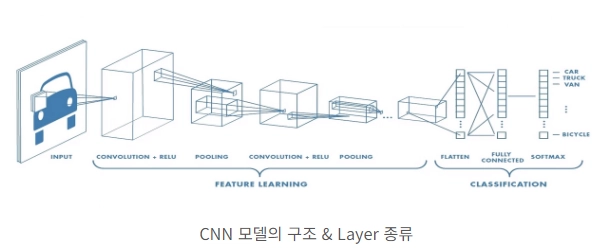  
  
- 위치 별 특징을 추출하는 부분과 클래스를 분류하는 부분으로 나눌 수 있음
- 특징 추출 영역: Convolution Layer와 Pooling Layer를 여러 겹 쌓는 형태로 구성
    - Convolution Layer: 입력 데이터에 필터를 적용 후 활성화 함수를 반영하는 필수 요소
    - Pooling Layer: Convolution Layer 다음에 위치하며, 이미지의 공간 크기를 줄여 중요한 특징을 강조하는 역할
        - 모델의 계산 효율성 높임
        - 과적합 방지
- 이미지 분류 영역: CNN 모델의 마지막에 위치하고 Fully Connected Layer로 구성
    - 회귀, 분류와 유사한 방식
- Feature Learning(Conv+Pool)과 Classification(FC Layer) 사이에 3차원을 1차원 배열 형태로 만드는 Flatten 위치
  

**Convolution Layer**  
> 전체 이미지를 일정 크기의 필터로 훑으면서 이미지의 특징을 학습  
  
1. 필터 또는 커널이 이미지 위를 슬라이딩
    - CNN의 필터 값은 MLP의 가중치 같은 역할을 함
2. 각 위치에서 요소별 곱셈 후 합계 계산
3. 결과를 Feature Map에 저장
    - Feature Map: input data에 filter를 적용하여 얻은 결과물
    - feature map의 차원은 filter 수에 따라 결정
    - 활성화된 정도를 나타낸다는 점에서 activation map이라고도 부름
  

**Padding**  
> filter를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법  
  
- 이미지 크기를 유지하면서 가장자리 특징까지 반영
  

**Stride**  
> 이미지를 몇 칸씩 점프하면서 훑을 것인지 결정하는 값  
  
- Stride=1: 한 칸씩 이동 (세밀한 특징 추출)
- Stride=2: 두 칸씩 이동 (빠른 처리, 크기 축소)
- 계산량 감소, 겹치는 영역을 줄여 효율적으로 요약
- stride 커질수록 feature map의 크기 작아짐
  

**Pooling**  
> 피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 *가장 큰값* 또는 *평균값*을 취하는 것  
  
- Max Pooling: 최댓값 선택
    - 주로 이 방법 사용
- Average Pooling: 평균값 선택
- 장점
    - 차원을 축소시켜 모델 용량, 계산량 감소
    - 노이즈를 제거하고 중요한 데이터만 유지
    - 불필요한 정보를 제거해 과적합 방지
- 단점
    - 정보 소실 위험
  
  
### 1-3. 대표적인 CNN 아키텍처
  
**AlexNet (2012)**  
> 머신러닝에서 벗어나 최초로 GPU 이용해 학습한 대규모 CNN 모델  
  
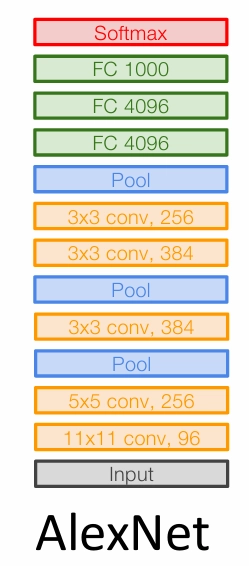  
  
- 5개의 Convolutional Layer + 3개의 Fully Connected Layer -> 총 8층 구조
- 활성화 함수로 ReLU 함수 사용해 기울기 소실 문제 해소 + 시그모이드보다 효율적인 학습
- Dropout을 통한 과적합 방지  
  
**VGGNet (2014)**  
> 이미지 인식에 강한 깊은 층의 CNN 모델  
  
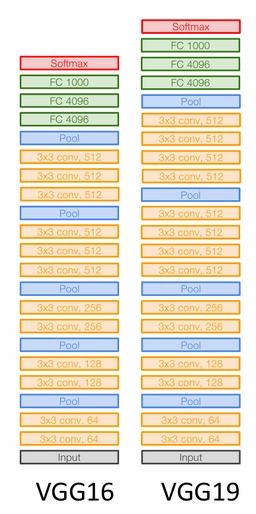  

- Conv+Pool(max)을 여러번 반복 
- Filter 크기가 3*3으로 고정
- 단순하지만 층의 깊이를 늘려 정확도 높임
- 이미 만들고 학습시킨 VGGNet 모델을 가져와 사용하는 전이 학습에 많이 사용
- 초반 연산량 매우 많음
  
**ResNet (2015)**  
> 잔차 연결 개념을 도입해 깊은 신경망의 소실 문제를 해결한 모델  
  
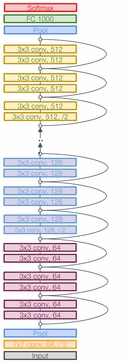  
  
- 잔차 연결: 이전 레이어의 출력을 몇 레이어를 건너 뛰고, 다음 레이어의 입력으로 직접 추가하는 방식
- 현재까지도 많은 모델의 기반이 되는 구조

## 2. 이미지 딥러닝 응용  
  
### 2-1. 이미지 분류  
  
이미지를 수치 데이터(픽셀 값)로 인식 -> 사전 정의된 클래스 중 하나로 분류  
  
[모델별 정리]  
- AlexNet
    - 비교적 단순한 구조
    - 초기 CNN 모델들
    - 작은 데이터셋이나 학습 개념 설명용으로 적절
- VGG
    - 더 깊은 구조
    - 복잡한 블록 구조 적용
    - 계산량 증대, 메모리 요구 높음
- ResNet
    - Residual 연결 (skip connections) -> 매우 깊은 네트워크 가능
    - 과적합 주의
    - Batch Size / Regularization 조절 필요
- Vision Transformer
    - Transformer 구조 응용 -> 패치 기반 입력 처리
    - 이미지와 순차 처리 모델의 결합
    - 대규모 데이터 필요

### 2-2. 객체 탐지  
  
**객체 검출**: 한 이미지에서 객차와 이 객체를 둘러싸는 가장 작은 직사각형(Bouncing Box)을 찾는 작업  
  
[모델 적용 방식]  
- CNN을 통해 Feature map 얻고, 그 위데 두 가지 head 올림
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측
- 대표 모델: YOLO, Faster R-CNN, SSD 등
  

### 2-3. 이미지 캡셔닝  
  
**Image Captioning**: 이미지 내에 있는 객체에 대한 판단뿐 아니라 *객체 간 관계*를 파악하고 자연어의 형태로 알맞게 표현  
  
[모델 적용 방식]  
- CNN: 이미지 특징 추출
- RNN: 문장으로 표현
  
[이미지 캡셔닝 단계]  
1. CNN을 이용하여 특징 추출
    - RG 3채널의 인풋 데이터를 ResNet-101을 활용하여 특징 추출
2. Attention Network를 이용하여 단어 생성
    - Attention Network 통과하여 중요한 부분에 가중치 둠 -> 단어 추출
    - 가중치 높은 부분을 이용해 사진을 한 문장으로 설명
3. RNN 이용하여 문장 생성
    - 가중치 바탕으로 추출해낸 이미지 주요 단어들을 RNN을 통해 조합 -> 문장 완성

## 3. RNN  
  
### 3-1. 순차(Sequence) 데이터  
  
**순차 데이터**: 순서에 의미가 있으며, 순서가 달라질 경우 의미가 손상되는 데이터  
- 음성 및 오디오 데이터: 소리의 파형이 연속적으로 변화
- 자연어: 맥락이 중요
- 생물학적 서열 데이터: DNA, 단백질 서열 등 특정 순서로 배열
- 비디오 데이터: 여러 이미지 프레임이 순서대로 나열
  
[기존 정형 데이터와의 차이]  
- 정형 데이터 특징
    - 샘플(행)의 독립성: 각 행은 독립적 정보를 나타내므로 순서 바뀌어도 데이터셋의 의미 변하지 않음
    - 특성(열)의 독립성: '나이, 키' 순서로 데이터를 분석하든, '키, 나이' 순서로 분석하든 각 특성이 담고 있는 정보는 동일
  
- 순차 데이터 특징
    - 요소의 순서 의존성: 데이터를 구성하는 요소들의 순서 자체가 핵심 정보
    - 자기상관성: 이전 시점의 데이터가 다음 시점의 데이터에 영향 미침
  
> 과거의 정보를 기억하고, 순서의 의미를 학습할 수 있는 특별한 신경망 필요!  
  
### 3-2. RNN의 구조와 원리  
  
**RNN**: 순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망  
- 시퀀스 데이터를 입력 받아 순서 정보 유지
- 순환하는 은닉층이 매 시점의 은닉 상태를 업데이트
- 이전 시점의 값을 현재 시점으로 넘겨줌
  
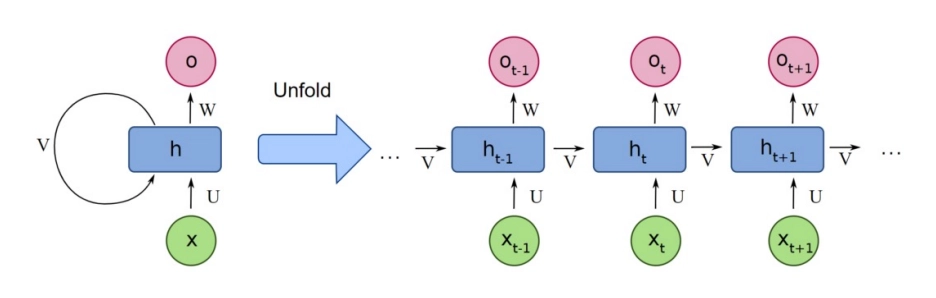  
  
- 초록: 입력층 / 파랑: 은닉층 / 분홍: 출력층
  
[용어]  
- $x_t$: 시간 t에서의 입력값
- $h_t$: 시간 t에서의 은닉 상태
- $o_t$: 시간 t에서의 출력
- $U$: 입력 가중치, 현재 시점의 입력값이 은닉 상태에 영향 주는 가중치
- $V$: 순환 가중치, 이전 시점의 은닉 상태가 현재 은닉 상태에 영향 주는 가중치
- $W$: 출력 가중치, 현재 시점의 은닉 상태가 최종 출력에 영향을 미치는 가중치
  
[정보 흐름]  
- t-1 시점: 입력 $x_{t-1}$이 들어가 은닉 상태 $h_{t-1}$을 업데이트, 출력 $o_{t-1}$을 내보냄
- t 시점: t-1시점에서 계산된 은닉 상태 $h_{t-1}$이 다음 시점으로 그대로 전달됨
- 새로운 입력 $x_t$와 전달받은 과거 정보 $h_{t-1}$을 함께 사용하여 현재 시점의 은닉 상태 $h_t$를 업데이트 하고, 출력 $o_t$를 계산함
  
> 은닉 상태의 순환을 통해 과거의 정보를 다음 시점으로 계속해서 전달  
  
**RNN 원리**: 가중치 공유  
  
- 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
- RNN이 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 하는 핵심 원리
  
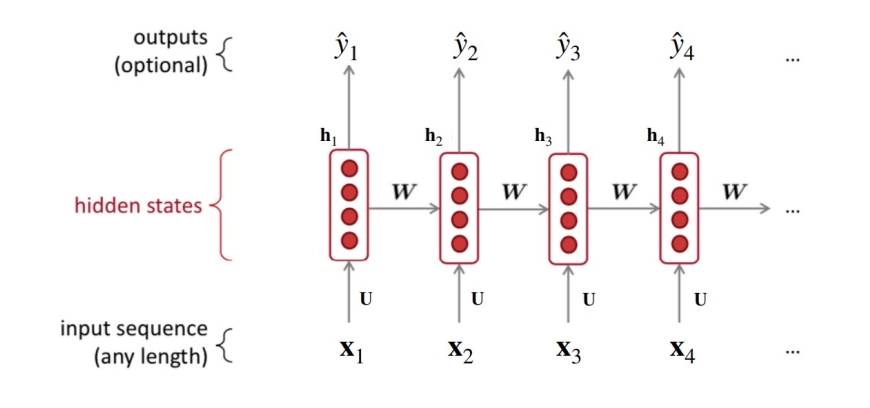  
  
- 모든 입력값을 처리할 때 동일한 파라미터를 공유함
    - 학습 파라미터 수 감소
    - 일반화 능력 향상
    - 새로운 길이의 시퀀스나 다양한 패턴에 유연하게 대응
  

### 3-3. RNN의 한계 및 장기 의존성 문제  
  
**RNN의 한계**: 전체 시퀀스를 모두 읽은 후 역전파 이루어짐
    - 역전파를 구하는 과정에서 Chain Rule에 의해 다음 미분 값이 반복적으로 곱해짐 (등비수열 형태)  
  
- 기울기 소실
    - 시퀀스 뒤쪽의 오차가 앞까지 제대로 전달 X -> 먼 과거의 정보 학습 불가
    - 역전파 과정에서 반복적으로 곱해지는 기울기의 크기가 1보다 작을 때 -> 기울기 0으로 수렴
- 기울기 폭주 -> (해결) Gradient Clipping
    - 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커집
    - 역전파 과정에서 반복적으로 곱해지는 기울기의 크기가 1보다 클 때 -> 기울기 무한대로 발산
- 느린 훈련 시간
    - 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계
    - 전체 시퀀스를 한 번에 병렬처리 불가
  
**장기 의존성 문제**: 시퀀스 앞 부분의 중요한 정보 잊어버려 맥락 파악 능력 저하  
- 단기 기억력은 준수 but 장기 기억력 문제  
- 새로운 모델의 필요성 대두
    - RNN의 기억력 한계 극복
    - 더 길고 복잡한 시퀀스 데이터 안정적으로 다룰 수 있어야 함
    - 중요한 정보는 오래 기억하고, 불필요한 정보는 잊는 메모리 구조

## 4. LSTM & GRU
  
**LSTM**: 장기기억과 단기기억 및 출력을 따로 분리해서 관리
- 셀 상태: 절대 변하지 않는 핵심 기억
- 엘리트: 현재 상황에서 바로 사용하는 기억, 셀 상태에서 필요한 정보만 꺼내서 지금 시점에서의 판단 혹은 출력으로 사용  
- 행동 방식
    - Forget Gate
    - Input Gate
    - Output Gate
  
**GRU**: 모든 기억과 행동이 하나의 상태로 통합되어 있음  
- Update Gate: 과거 기억 vs 새 정보, 뭐가 더 중요한지?
- Reset Gate: 과거 기억 얼마나 무시?  
  
### 4-1. LSTM: 게이트로 정보의 흐름 제어  
  
**LSTM**  
- 앞의 정보가 뒤로 충분히 전달되지 못하는 RNN의 *기울기 소실 문제*를 해결하기 위한 모델 구조  
  
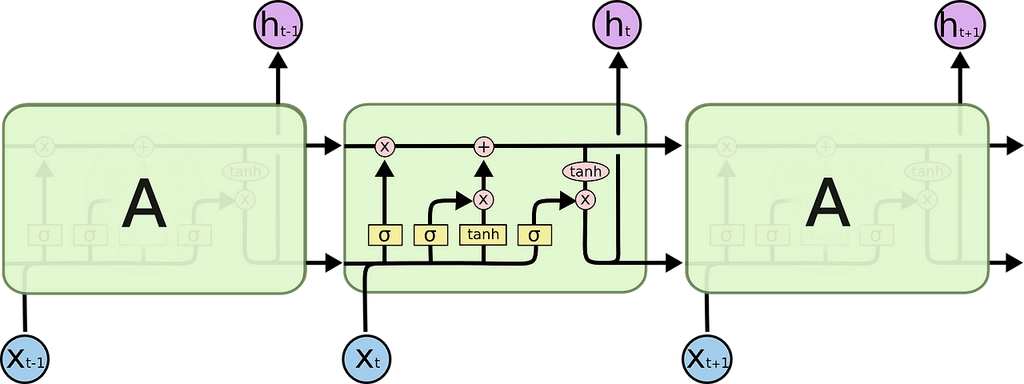  
  
- 기억할 내용과 잊어버릴 내용을 선택해서, 중요한 정보를 오래 가져감
    - GATE를 통해 곱셈을 덧셈으로 바꿈
- RNN과 차이: $c_t$(cell state, 장기 기억)와 $h_t$(hidden state, 단기 기억)의 2개의 순환되는 층 사용  
- Gate를 통해 필요한 정보만 통과
    - Forget Gate: 정보를 얼마나 잊어버릴지
    - Input Gate: 현재 정보를 얼마나 사용할지
    - Output Gate: 다음 층으로 어떤 정보를 전달할지
- Final memory cell: Input, forget gate를 결합해 현재 정보를 얼마나 기억할지 계산
  
- 장점: 기울기 소실 문제 효과적으로 완화
    - Gate를 통해 기억할 정보, 잊을 정보 나눠서 관리
    - 중요한 정보는 완전히 보존되는 상태로 갱신 가능
- 단점: 복잡한 구조, 학습 파라미터 많음
  
### 4-2. GRU: 단순하고 효율적인 구조  
  
**GRU**  
- LSTM에서 발전, 별도의 메모리 셀 없이 게이트 수를 줄여 구조 간소화
  
[LSTM과 차이]  
- Forget gate와 Input gate를 Update gate 하나로 합침
- Reset gate 사용
- Gate 개수 3개에서 2개로 줄어 학습 시간 감소
  
- 장점: 성능-효율성 사이 균형 좋음
- 단점: 긴 시퀀스 처리에서의 한계 여전히 존재
  
### 4-3. LSTM vs GRU  
  
- LSTM 적합
    - 긴 시퀀스에서 문맥 이해 중요
    - 데이터 양 충분, 복잡한 패턴 학습
    - 모델 성능이 계산 효율보다 중요
    - 기계 번역, 언어 모델링, 장기 시계열 예측
- GRU 적합
    - 자원이 제한적이거나 학습 속도 중요
    - 데이터 양 적고, 과적합 위험
    - 실시간 예측이 필요한 응용
    - 음성 인식, 스트리밍 데이터, 실시간 비디오 분석, 짧은 시퀀스 기반의 텍스트 분류

## 5. Seq2Seq: 문장을 입력 받아 문장을 출력  
  
### 5-1. Seq2Seq 기본 구조  
  
**Seq2Seq**: 한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델  
  
- 아이템의 입력 개수와 출력 개수 달라도 됨
- 인코더, 디코더 모듈 포함
  
  
**인코더**: 입력된 시퀀스를 읽고 압축하여 디코더에게 넘겨줄 문맥 정보 준비  
- t 시점에서 임베딩된 단어의 입력과 t-1 시점의 은닉 상태가 RNN/LSTM의 입력으로 주어짐 -> 결과로 t 시점의 은닉 상태 나옴
  
**디코더**: 압축된 정보를 바탕으로 원하는 시퀀스 생성  
- 인코더가 보내준 컨텍스트 벡터가 디코더의 첫번째 은닉 상태에 사용
- t시점에 나온 출력값이 그 다음 시점의 입력값으로 넘어감  
  
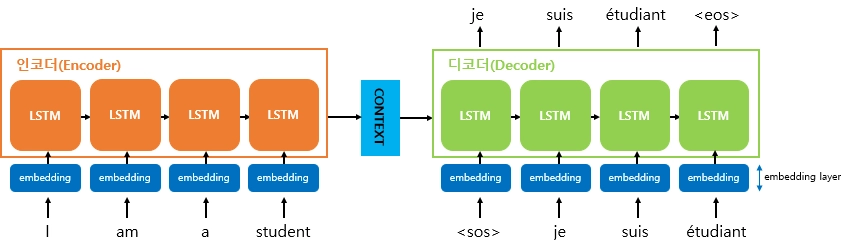  
  
- 인코더와 디코더를 모두 그림과 같이 RNN을 여러개 조합한 형태
- 모든 단어는 워드 임베딩 과정 거침
  
**컨텍스트 벡터**: 인코더 중 마지막 시점의 은닉 상태를 의미  
- 입력 시퀀스의 요약 정보처럼 작동
- float 형의 벡터이며 차원은 직접 설정 가능 
  

### 5-2. Seq2Seq 한계: 병목 현상  
  
> 고정된 Context Vector에 소스 문장의 정보를 압축하므로 병목현상 발생  
  
- 고정된 길이에 입력 시퀀스의 모든 정보를 담지 못하고 손실될 수 있음
- 특히 긴 입력 시퀀스의 경우 정보 손실 심각, 모델 성능 하락으로 이어짐
  
[추가 한계]  
- 기울기 소실 문제 발생
- 병렬화 불가능 문제